# NEPSE Commercial Bank Stock — ML Momentum Signal System
### HistGradientBoosting · Buy / Sell / Hold · 5-Day Forward Return · Live Inference Ready

**Dataset:** 17 NEPSE commercial banks · 2011–2025 · Daily OHLCV + Macro  
**Target:** 5-day forward return → Buy / Sell / Hold classification  
**Inference:** Designed for live OHLCV scraper (last ~1 year of data per bank)

---


## 0. Imports & Configuration

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.cluster import KMeans

import pickle, json, os, datetime

# ── Reproducibility ──────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Signal Parameters ────────────────────────────────────────────
FORWARD_DAYS = 5          # momentum horizon (5-day)
BUY_PCTILE   = 70         # top 30% forward returns  → BUY
SELL_PCTILE  = 30         # bottom 30% forward returns → SELL
                          # middle 40%               → HOLD

# ── Paths ────────────────────────────────────────────────────────
DATA_PATH  = 'combinedBankData.csv'   # update path as needed
OUTPUT_DIR = 'nepse_model_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded successfully")
print(f"  Forward horizon : {FORWARD_DAYS} days")
print(f"  Buy  threshold  : top {100-BUY_PCTILE}% returns")
print(f"  Sell threshold  : bottom {SELL_PCTILE}% returns")


Configuration loaded successfully
  Forward horizon : 5 days
  Buy  threshold  : top 30% returns
  Sell threshold  : bottom 30% returns


## 1. Data Loading & Validation

In [5]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_raw = df_raw.sort_values(['bank', 'date']).reset_index(drop=True)

print(f"Shape        : {df_raw.shape}")
print(f"Banks ({df_raw['bank'].nunique()}) : {sorted(df_raw['bank'].unique())}")
print(f"Date range   : {df_raw['date'].min().date()} -> {df_raw['date'].max().date()}")
print(f"Nulls        : {df_raw.isnull().sum().sum()}")
print()
display(df_raw.head(3))


Shape        : (50141, 17)
Banks (17) : ['ADBL', 'CZBIL', 'EBL', 'GBIME', 'HBL', 'KBL', 'MBL', 'NABIL', 'NBL', 'NICA', 'NMB', 'PCBL', 'PRVU', 'SANIMA', 'SBI', 'SBL', 'SCB']
Date range   : 2011-11-13 -> 2025-10-19
Nulls        : 0



,date,open,high,low,close,per_change,volume,amount,bank,nepse_close,nepse_bull,nepse_ret_1d,nepse_ret_5d,nepse_ret_21d,policy_rate,car,npl
0,2011-11-13,119.0,120.0,118.0,120.0,0.84,1164.0,139094.0,ADBL,331.0,0.0,-0.003012,-0.037791,0.000000,7.0,19.95,8.64
1,2011-11-14,120.0,122.0,114.0,122.0,1.67,2691.0,314662.0,ADBL,331.0,0.0,0.000000,-0.020710,0.000000,7.0,19.95,8.64
2,2011-11-15,121.0,121.0,118.0,119.0,-2.46,1157.0,138490.0,ADBL,327.0,0.0,-0.012085,-0.023881,-0.018018,7.0,19.95,8.64


In [6]:
# ── Drop columns NOT reproducible at inference time ───────────────
# per_change  : re-derived from close prices
# amount      : turnover proxy, not cleanly scraped
DROP_COLS = ['per_change', 'amount']
df_raw = df_raw.drop(columns=[c for c in DROP_COLS if c in df_raw.columns])


## 2. Exploratory Data Analysis

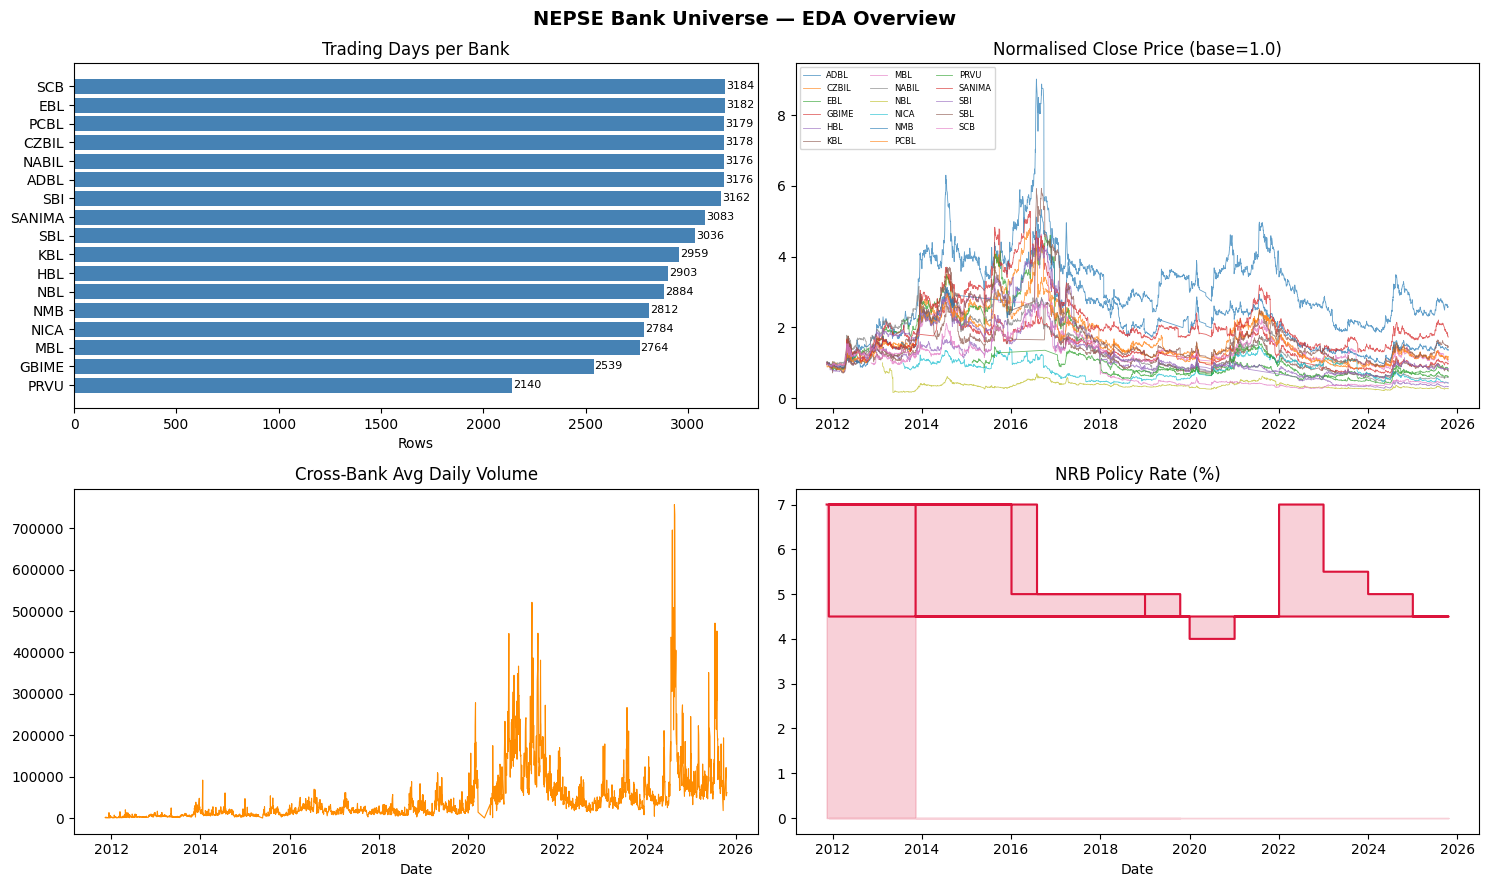

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('NEPSE Bank Universe — EDA Overview', fontsize=14, fontweight='bold')

# 1) Rows per bank
bank_counts = df_raw.groupby('bank').size().sort_values(ascending=True)
axes[0,0].barh(bank_counts.index, bank_counts.values, color='steelblue')
axes[0,0].set_title('Trading Days per Bank'); axes[0,0].set_xlabel('Rows')
for i, v in enumerate(bank_counts.values):
    axes[0,0].text(v+5, i, str(v), va='center', fontsize=8)

# 2) Normalised price trajectories
for bank, g in df_raw.groupby('bank'):
    s = g.set_index('date')['close']
    axes[0,1].plot(s / s.iloc[0], linewidth=0.6, alpha=0.7, label=bank)
axes[0,1].set_title('Normalised Close Price (base=1.0)')
axes[0,1].legend(fontsize=6, ncol=3, loc='upper left')

# 3) Average daily volume over time
vol_ts = df_raw.groupby('date')['volume'].mean()
axes[1,0].plot(vol_ts.index, vol_ts.values, linewidth=0.8, color='darkorange')
axes[1,0].set_title('Cross-Bank Avg Daily Volume'); axes[1,0].set_xlabel('Date')

# 4) Policy rate over time
macro = df_raw[['date','policy_rate']].drop_duplicates().set_index('date')
axes[1,1].step(macro.index, macro['policy_rate'], color='crimson', linewidth=1.5, where='post')
axes[1,1].set_title('NRB Policy Rate (%)'); axes[1,1].set_xlabel('Date')
axes[1,1].fill_between(macro.index, macro['policy_rate'], alpha=0.2, color='crimson', step='post')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Feature Engineering

All features derived **exclusively from OHLCV + macro inputs** —  
guaranteed reproducible from live scraped data.  
No future information used. Computed per-bank to prevent cross-contamination.


In [8]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute all features per-bank on a sorted time-series.
    Inputs  : date, open, high, low, close, volume,
              nepse_close, nepse_ret_1d/5d/21d, policy_rate, car, npl, bank
    Returns : original df + all feature columns (no lookahead)
    """
    df = df.copy().sort_values(['bank', 'date']).reset_index(drop=True)
    out_frames = []

    for bank, g in df.groupby('bank'):
        g = g.copy().reset_index(drop=True)

        c  = g['close']
        h  = g['high']
        lo = g['low']
        v  = g['volume']
        o  = g['open']
        nc = g['nepse_close']

        # 1. Returns (log-scale, shift-based — no future data)
        g['log_ret_1d']  = np.log(c / c.shift(1))
        g['log_ret_3d']  = np.log(c / c.shift(3))
        g['log_ret_5d']  = np.log(c / c.shift(5))
        g['log_ret_10d'] = np.log(c / c.shift(10))
        g['log_ret_21d'] = np.log(c / c.shift(21))

        # 2. Trend — Moving Averages
        g['sma_5']  = c.rolling(5).mean()
        g['sma_21'] = c.rolling(21).mean()
        g['sma_63'] = c.rolling(63).mean()
        g['ema_9']  = c.ewm(span=9,  adjust=False).mean()
        g['ema_21'] = c.ewm(span=21, adjust=False).mean()

        # Price vs MA (scale-invariant ratios)
        g['price_to_sma5']  = c / g['sma_5']  - 1
        g['price_to_sma21'] = c / g['sma_21'] - 1
        g['price_to_sma63'] = c / g['sma_63'] - 1
        g['sma5_to_sma21']  = g['sma_5']  / g['sma_21'] - 1   # golden-cross proxy
        g['sma21_to_sma63'] = g['sma_21'] / g['sma_63'] - 1   # trend regime

        # 3. Momentum oscillators
        # RSI (14)
        delta = c.diff()
        gain  = delta.clip(lower=0).rolling(14).mean()
        loss  = (-delta.clip(upper=0)).rolling(14).mean()
        g['rsi_14'] = 100 - (100 / (1 + gain / (loss + 1e-9)))

        # RSI (28) — slower momentum
        gain2 = delta.clip(lower=0).rolling(28).mean()
        loss2 = (-delta.clip(upper=0)).rolling(28).mean()
        g['rsi_28'] = 100 - (100 / (1 + gain2 / (loss2 + 1e-9)))

        # MACD (normalised by price for scale-invariance)
        ema12 = c.ewm(span=12, adjust=False).mean()
        ema26 = c.ewm(span=26, adjust=False).mean()
        macd        = ema12 - ema26
        macd_signal = macd.ewm(span=9, adjust=False).mean()
        g['macd_norm']      = macd / (c + 1e-9)
        g['macd_hist_norm'] = (macd - macd_signal) / (c + 1e-9)

        # Rate of Change
        g['roc_5']  = c.pct_change(5)
        g['roc_21'] = c.pct_change(21)

        # 4. Volatility
        g['vol_21']    = g['log_ret_1d'].rolling(21).std()
        g['vol_63']    = g['log_ret_1d'].rolling(63).std()
        g['vol_ratio'] = g['vol_21'] / (g['vol_63'] + 1e-9)  # vol regime

        # ATR (normalised)
        tr = pd.concat([h - lo,
                        (h - c.shift(1)).abs(),
                        (lo - c.shift(1)).abs()], axis=1).max(axis=1)
        g['atr_14_norm'] = tr.rolling(14).mean() / (c + 1e-9)

        # Bollinger Bands
        bb_mid = c.rolling(20).mean()
        bb_std = c.rolling(20).std()
        g['bb_width'] = (2 * bb_std) / (bb_mid + 1e-9)
        g['bb_pct']   = (c - (bb_mid - 2*bb_std)) / (4*bb_std + 1e-9)

        # 5. Candle structure
        g['hl_ratio']     = (h - lo) / (c + 1e-9)
        g['co_ratio']     = (c - o)  / (h - lo + 1e-9)
        g['upper_shadow'] = (h - np.maximum(o, c)) / (h - lo + 1e-9)
        g['lower_shadow'] = (np.minimum(o, c) - lo) / (h - lo + 1e-9)

        # 6. Volume features
        v_ma20 = v.rolling(20).mean()
        g['vol_ratio_20'] = v / (v_ma20 + 1e-9)
        g['vol_ma5_ma20'] = v.rolling(5).mean() / (v_ma20 + 1e-9)

        # On-Balance Volume momentum (normalised to remove level drift)
        obv     = (np.sign(g['log_ret_1d']) * v).cumsum()
        obv_std = obv.rolling(21).std()
        g['obv_momentum'] = obv.diff(5) / (obv_std + 1e-9)

        # Price-volume divergence
        g['pv_divergence'] = g['log_ret_5d'] * (1 - g['vol_ratio_20'])

        # 7. 52-week position
        g['pct_from_52w_high'] = c / c.rolling(252).max() - 1
        g['pct_from_52w_low']  = c / c.rolling(252).min() - 1

        # 8. Market-relative (alpha vs NEPSE)
        nepse_ret_1d = np.log(nc / nc.shift(1))
        g['alpha_1d']  = g['log_ret_1d']  - nepse_ret_1d
        g['alpha_5d']  = g['log_ret_5d']  - g['nepse_ret_5d']
        g['alpha_21d'] = g['log_ret_21d'] - g['nepse_ret_21d']

        # NEPSE bull regime (re-derived — replicable in inference)
        g['nepse_bull_derived'] = (nc.rolling(21).mean() > nc.rolling(63).mean()).astype(int)

        # 9. Time / regime features
        g['month']        = g['date'].dt.month
        g['quarter']      = g['date'].dt.quarter
        g['day_of_week']  = g['date'].dt.dayofweek
        g['fiscal_q']     = ((g['date'].dt.month - 7) % 12 // 3 + 1)  # Nepal fiscal year

        # COVID regime flag (Nepal market disruption: Feb 2020 – Dec 2021)
        g['covid_regime']     = ((g['date'] >= '2020-02-01') &
                                  (g['date'] <= '2021-12-31')).astype(int)
        # High-rate regime (NRB tightening)
        g['high_rate_regime'] = (g['policy_rate'] >= 5.5).astype(int)

        # Rolling z-scores (local normalisation — no global scale leak)
        g['close_zscore_63'] = (c - c.rolling(63).mean()) / (c.rolling(63).std() + 1e-9)
        g['vol_zscore_63']   = (v - v.rolling(63).mean()) / (v.rolling(63).std() + 1e-9)

        # 10. Macro (manually provided at inference)
        g['policy_rate_chg'] = g['policy_rate'].diff().fillna(0)
        g['car_chg']         = g['car'].diff().fillna(0)
        g['npl_chg']         = g['npl'].diff().fillna(0)

        out_frames.append(g)

    result = pd.concat(out_frames, ignore_index=True)
    return result.sort_values(['bank', 'date']).reset_index(drop=True)


print("Engineering features on full dataset...")
df_feat = engineer_features(df_raw)
print(f"Shape after engineering: {df_feat.shape}")

NEW_FEAT_COLS = [
    'log_ret_1d','log_ret_3d','log_ret_5d','log_ret_10d','log_ret_21d',
    'price_to_sma5','price_to_sma21','price_to_sma63','sma5_to_sma21','sma21_to_sma63',
    'rsi_14','rsi_28','macd_norm','macd_hist_norm','roc_5','roc_21',
    'vol_21','vol_63','vol_ratio','atr_14_norm','bb_width','bb_pct',
    'hl_ratio','co_ratio','upper_shadow','lower_shadow',
    'vol_ratio_20','vol_ma5_ma20','obv_momentum','pv_divergence',
    'pct_from_52w_high','pct_from_52w_low',
    'alpha_1d','alpha_5d','alpha_21d','nepse_bull_derived',
    'nepse_ret_1d','nepse_ret_5d','nepse_ret_21d',
    'close_zscore_63','vol_zscore_63','covid_regime','high_rate_regime',
    'month','quarter','day_of_week','fiscal_q',
    'policy_rate','policy_rate_chg','car','car_chg','npl','npl_chg',
]
print(f"Total engineered features: {len(NEW_FEAT_COLS)}")


Engineering features on full dataset...
Shape after engineering: (50141, 67)
Total engineered features: 53


## 4. Target Construction — 5-Day Forward Return

Thresholds are **adaptive per-bank** (percentile-based over full history).  
This prevents biasing signal definitions toward any single price level regime.

| Signal | Condition |
|--------|-----------|
| **BUY**  | 5d forward return > 70th percentile (bank-specific) |
| **SELL** | 5d forward return < 30th percentile (bank-specific) |
| **HOLD** | otherwise |


In [9]:
def assign_labels(df: pd.DataFrame,
                  forward_days: int = 5,
                  buy_pctile: float = 70,
                  sell_pctile: float = 30) -> pd.DataFrame:
    """
    Compute 5-day forward return and assign Buy / Sell / Hold.
    Thresholds computed per-bank over full history.
    Last `forward_days` rows per bank are dropped (no forward return available).
    """
    df = df.copy()
    frames = []

    for bank, g in df.groupby('bank'):
        g = g.copy().reset_index(drop=True)
        fwd_ret = np.log(g['close'].shift(-forward_days) / g['close'])
        g['fwd_ret_5d'] = fwd_ret

        valid    = fwd_ret.dropna()
        buy_thr  = np.percentile(valid, buy_pctile)
        sell_thr = np.percentile(valid, sell_pctile)

        def label(r):
            if pd.isna(r): return np.nan
            if r > buy_thr:  return 'Buy'
            if r < sell_thr: return 'Sell'
            return 'Hold'

        g['signal'] = g['fwd_ret_5d'].apply(label)
        g['buy_thr']  = buy_thr
        g['sell_thr'] = sell_thr
        frames.append(g)

    result = pd.concat(frames, ignore_index=True)
    result = result.sort_values(['bank','date']).reset_index(drop=True)
    return result.dropna(subset=['signal']).reset_index(drop=True)


df_labeled = assign_labels(df_feat, FORWARD_DAYS, BUY_PCTILE, SELL_PCTILE)

print("Label distribution (all banks):")
print(df_labeled['signal'].value_counts())
print()
print("Per-bank distribution:")
print(df_labeled.groupby('bank')['signal'].value_counts().unstack().fillna(0).astype(int))


Label distribution (all banks):
signal
Hold    20029
Buy     15016
Sell    15011
Name: count, dtype: int64

Per-bank distribution:
signal  Buy  Hold  Sell
bank                   
ADBL    951  1269   951
CZBIL   952  1269   952
EBL     952  1272   953
GBIME   760  1014   760
HBL     870  1158   870
KBL     886  1182   886
MBL     828  1103   828
NABIL   951  1269   951
NBL     864  1152   863
NICA    834  1111   834
NMB     842  1123   842
PCBL    952  1270   952
PRVU    641   853   641
SANIMA  924  1230   924
SBI     947  1268   942
SBL     908  1215   908
SCB     954  1271   954


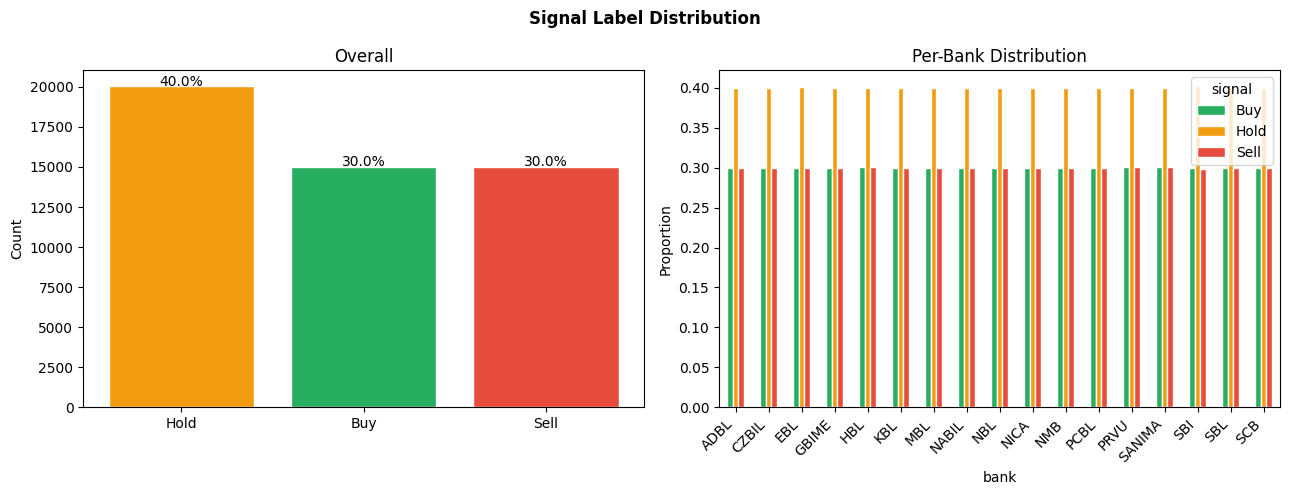

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Signal Label Distribution', fontweight='bold')
C = {'Buy':'#27ae60','Hold':'#f39c12','Sell':'#e74c3c'}

counts = df_labeled['signal'].value_counts()
axes[0].bar(counts.index, counts.values, color=[C[s] for s in counts.index], edgecolor='white')
axes[0].set_title('Overall'); axes[0].set_ylabel('Count')
for i,(k,v) in enumerate(counts.items()):
    axes[0].text(i, v+50, f'{v/len(df_labeled)*100:.1f}%', ha='center')

bd = df_labeled.groupby('bank')['signal'].value_counts(normalize=True).unstack().fillna(0)
bd[['Buy','Hold','Sell']].plot(kind='bar', ax=axes[1],
    color=[C['Buy'],C['Hold'],C['Sell']], edgecolor='white')
axes[1].set_title('Per-Bank Distribution'); axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Bank Clustering — Returns, Volatility, Correlation

In [11]:
# Per-bank profile
bp_dict = {}
for bank, g in df_labeled.groupby('bank'):
    ret = g['log_ret_1d'].dropna()
    cum = (1 + ret).cumprod()
    bp_dict[bank] = {
        'ann_return'  : ret.mean() * 252,
        'ann_vol'     : ret.std()  * np.sqrt(252),
        'sharpe'      : (ret.mean() / (ret.std() + 1e-9)) * np.sqrt(252),
        'skew'        : float(ret.skew()),
        'kurt'        : float(ret.kurt()),
        'max_drawdown': float((cum / cum.cummax() - 1).min()),
    }

bp = pd.DataFrame(bp_dict).T
print("Bank risk profiles:")
print(bp.round(4))

# K-Means on standardised profiles
X_clust = StandardScaler().fit_transform(bp)
km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
bp['cluster'] = km.fit_predict(X_clust)
cluster_map   = bp['cluster'].to_dict()

print("\nCluster assignments:")
for c in sorted(bp['cluster'].unique()):
    members = bp[bp['cluster']==c].index.tolist()
    profile = bp[bp['cluster']==c][['ann_return','ann_vol','sharpe']].mean()
    print(f"  Cluster {c}: {members}")
    print(f"    annRet={profile['ann_return']*100:.1f}%  annVol={profile['ann_vol']*100:.1f}%  Sharpe={profile['sharpe']:.2f}")

df_labeled['bank_cluster'] = df_labeled['bank'].map(cluster_map)


Bank risk profiles:
        ann_return  ann_vol  sharpe     skew      kurt  max_drawdown
ADBL        0.0749   0.3696  0.2026  -1.4799   31.4826       -0.8665
CZBIL       0.0121   0.3571  0.0338  -1.2259   22.2320       -0.8781
EBL        -0.0186   0.3786 -0.0491  -5.7672  122.0382       -0.9393
GBIME      -0.0021   0.3367 -0.0062  -0.4916   12.4918       -0.8493
HBL        -0.0966   0.3763 -0.2567  -2.6133   34.0921       -0.9349
KBL        -0.0190   0.3962 -0.0478  -2.0985   42.9355       -0.8902
MBL         0.0056   0.3641  0.0153  -1.4635   30.5810       -0.8888
NABIL      -0.0424   0.3514 -0.1206  -3.0579   42.2419       -0.9167
NBL        -0.1140   0.5095 -0.2237 -23.0893  934.4817       -1.6531
NICA       -0.0749   0.3566 -0.2101  -2.9880   45.5000       -0.8422
NMB         0.0285   0.3528  0.0808  -0.2756    9.9072       -0.8691
PCBL        0.0074   0.3626  0.0204  -1.3456   18.9469       -0.8721
PRVU       -0.0560   0.3414 -0.1641  -0.3160   10.8238       -0.8042
SANIMA      0.

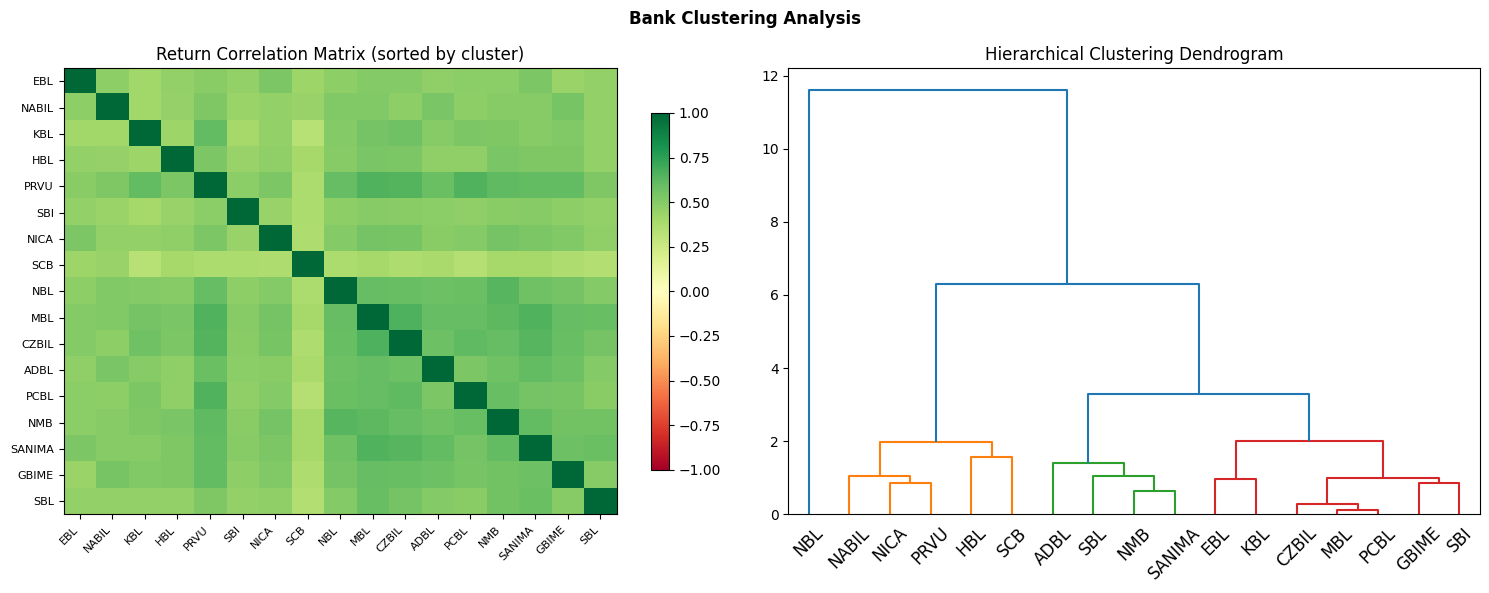

In [12]:
# Correlation heatmap + dendrogram
ret_wide = df_labeled.pivot_table(index='date', columns='bank', values='log_ret_1d').dropna()
corr     = ret_wide.corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Bank Clustering Analysis', fontweight='bold')

cluster_order = bp.sort_values('cluster').index.tolist()
im = axes[0].imshow(corr.loc[cluster_order, cluster_order].values,
                    cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(cluster_order))); axes[0].set_yticks(range(len(cluster_order)))
axes[0].set_xticklabels(cluster_order, rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(cluster_order, fontsize=8)
axes[0].set_title('Return Correlation Matrix (sorted by cluster)')
plt.colorbar(im, ax=axes[0], shrink=0.8)

Z = linkage(X_clust, method='ward')
dendrogram(Z, labels=bp.index.tolist(), leaf_rotation=45, ax=axes[1], color_threshold=Z[-3,2])
axes[1].set_title('Hierarchical Clustering Dendrogram')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_bank_clustering.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Dataset Preparation for Modelling

In [13]:
# Encode target
le = LabelEncoder()
df_labeled['label'] = le.fit_transform(df_labeled['signal'])
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label encoding:", label_map)

# Encode bank
bank_le = LabelEncoder()
df_labeled['bank_enc'] = bank_le.fit_transform(df_labeled['bank'])

# Full feature list (selected after feature selection step below)
FEATURE_COLS = NEW_FEAT_COLS + ['bank_enc', 'bank_cluster']
print(f"Total candidate features: {len(FEATURE_COLS)}")

# Drop rows with NaN in any feature (due to rolling lookback warmup)
df_model = df_labeled.dropna(subset=FEATURE_COLS + ['label']).reset_index(drop=True)
print(f"Model-ready rows: {df_model.shape[0]}  (from {df_labeled.shape[0]})")
print()
print("Final label distribution:")
print(df_model['signal'].value_counts())


Label encoding: {'Buy': np.int64(0), 'Hold': np.int64(1), 'Sell': np.int64(2)}
Total candidate features: 55
Model-ready rows: 45789  (from 50056)

Final label distribution:
signal
Hold    18648
Sell    13751
Buy     13390
Name: count, dtype: int64


## 7. Time-Series Cross-Validation

**Why `TimeSeriesSplit`?**  
- Preserves temporal order — no future data in training fold  
- `gap=FORWARD_DAYS` prevents label leakage between folds  

**Why `HistGradientBoostingClassifier`?**  
- Handles tabular financial data with mixed-scale features natively  
- Built-in `class_weight='balanced'` solves the Buy/Hold/Sell imbalance  
- 10–50× faster than vanilla GBM on 50K rows — practical for iterative selection  
- Competitive with XGBoost/LightGBM with no external dependencies  
- Native NaN handling for early rolling-window rows  


In [14]:
X      = df_model[FEATURE_COLS].values
y      = df_model['label'].values
dates  = df_model['date'].values

N_SPLITS  = 5
tscv      = TimeSeriesSplit(n_splits=N_SPLITS, gap=FORWARD_DAYS)

MODEL_PARAMS = dict(
    max_iter          = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_samples_leaf  = 30,
    l2_regularization = 0.5,
    max_bins          = 255,
    class_weight      = 'balanced',
    random_state      = RANDOM_STATE,
    early_stopping    = False,
    validation_fraction = None,
)

cv_results_s1 = []
print(f"Stage-1 CV ({N_SPLITS} folds) — {len(FEATURE_COLS)} features")
print("=" * 65)

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    m = HistGradientBoostingClassifier(**MODEL_PARAMS)
    m.fit(X_tr, y_tr)

    proba  = m.predict_proba(X_te)
    y_pred = m.predict(X_te)

    try:
        auc = roc_auc_score(y_te, proba, multi_class='ovr', average='macro')
    except Exception:
        auc = 0.0
    f1_mac = f1_score(y_te, y_pred, average='macro', zero_division=0)
    dr = f"{pd.Timestamp(dates[te_idx[0]]).date()} to {pd.Timestamp(dates[te_idx[-1]]).date()}"
    print(f"Fold {fold+1} | {dr} | AUC={auc:.4f}  F1={f1_mac:.4f}")
    cv_results_s1.append({'fold': fold+1, 'auc': auc, 'f1_macro': f1_mac})

cv_s1 = pd.DataFrame(cv_results_s1)
print("=" * 65)
print(f"Stage-1  Mean AUC={cv_s1['auc'].mean():.4f} +/- {cv_s1['auc'].std():.4f}")
print(f"Stage-1  Mean F1 ={cv_s1['f1_macro'].mean():.4f} +/- {cv_s1['f1_macro'].std():.4f}")


Stage-1 CV (5 folds) — 55 features
Fold 1 | 2020-12-06 to 2020-09-24 | AUC=0.6471  F1=0.4538
Fold 2 | 2020-09-27 to 2018-12-05 | AUC=0.7209  F1=0.5404
Fold 3 | 2018-12-06 to 2017-04-24 | AUC=0.7429  F1=0.5580
Fold 4 | 2017-04-25 to 2017-05-17 | AUC=0.7842  F1=0.6077
Fold 5 | 2017-05-18 to 2025-10-12 | AUC=0.7600  F1=0.5870
Stage-1  Mean AUC=0.7311 +/- 0.0523
Stage-1  Mean F1 =0.5494 +/- 0.0594


## 8. Stage-1 Model — Feature Importance (Permutation)

In [15]:
print("Training Stage-1 model on 100% data for importance analysis...")
model_s1 = HistGradientBoostingClassifier(**MODEL_PARAMS)
model_s1.fit(X, y)

# Permutation importance on last 20% temporal holdout (importance analysis only)
ho = int(len(X) * 0.80)
print(f"Computing permutation importance on last 20% ({len(X)-ho} rows)...")

perm = permutation_importance(
    model_s1, X[ho:], y[ho:],
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='f1_macro', n_jobs=-1
)

imp_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': perm.importances_mean,
    'std'       : perm.importances_std,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop 20 features:")
print(imp_df.head(20).to_string(index=False))


Training Stage-1 model on 100% data for importance analysis...
Computing permutation importance on last 20% (9158 rows)...

Top 20 features:
          feature  importance      std
            month    0.097233 0.002969
    nepse_ret_21d    0.088607 0.001955
     nepse_ret_5d    0.067349 0.003485
     nepse_ret_1d    0.046606 0.002208
pct_from_52w_high    0.038763 0.001558
 pct_from_52w_low    0.038563 0.001614
      policy_rate    0.036850 0.002635
         bb_width    0.027865 0.001851
   sma21_to_sma63    0.026412 0.001919
              npl    0.025702 0.001568
           vol_63    0.025658 0.001403
      atr_14_norm    0.022554 0.002062
              car    0.021377 0.001631
  close_zscore_63    0.020253 0.001540
           rsi_14    0.018643 0.000993
      log_ret_21d    0.017739 0.000806
           vol_21    0.016589 0.001205
           rsi_28    0.016501 0.001185
        vol_ratio    0.016101 0.001368
    price_to_sma5    0.015730 0.000824


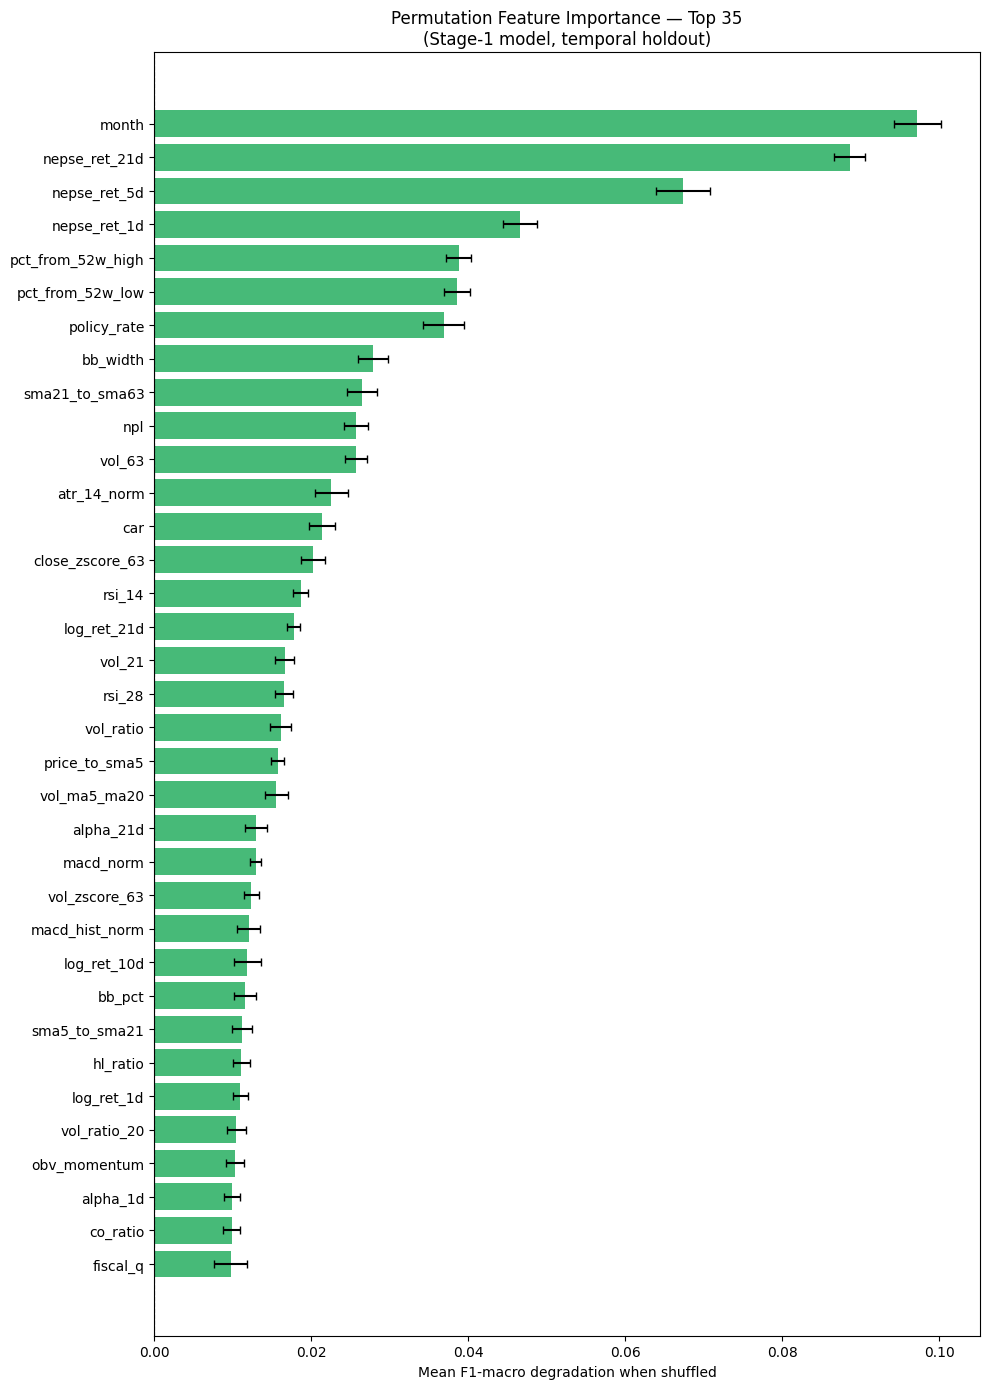

In [16]:
fig, ax = plt.subplots(figsize=(10, 14))
top_n   = 35
top_imp = imp_df.head(top_n).sort_values('importance')
colors  = ['#27ae60' if v > 0 else '#e74c3c' for v in top_imp['importance']]
ax.barh(top_imp['feature'], top_imp['importance'],
        xerr=top_imp['std'], color=colors, alpha=0.85, capsize=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'Permutation Feature Importance — Top {top_n}\n(Stage-1 model, temporal holdout)')
ax.set_xlabel('Mean F1-macro degradation when shuffled')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_feature_importance_stage1.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Feature Selection → Stage-2 Model

Features with **permutation importance < 0.001** are removed —  
they add noise without improving signal, and may hurt generalisation.


In [17]:
IMPORTANCE_THRESHOLD = 0.001

selected_features = imp_df[imp_df['importance'] >= IMPORTANCE_THRESHOLD]['feature'].tolist()
dropped_features  = imp_df[imp_df['importance'] <  IMPORTANCE_THRESHOLD]['feature'].tolist()

print(f"Features selected : {len(selected_features)}")
print(f"Features dropped  : {len(dropped_features)}")
if dropped_features:
    print(f"  Dropped: {dropped_features}")

# Rebuild feature matrix
feat_idx = [FEATURE_COLS.index(f) for f in selected_features]
X_sel    = X[:, feat_idx]
print(f"New X shape: {X_sel.shape}")


Features selected : 48
Features dropped  : 7
  Dropped: ['bank_cluster', 'npl_chg', 'policy_rate_chg', 'roc_21', 'roc_5', 'quarter', 'car_chg']
New X shape: (45789, 48)


In [18]:
# Stage-2 CV with selected features
print(f"Stage-2 CV ({N_SPLITS} folds) — {len(selected_features)} features")
print("=" * 65)

cv_results_s2 = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_sel)):
    m2 = HistGradientBoostingClassifier(**MODEL_PARAMS)
    m2.fit(X_sel[tr_idx], y[tr_idx])

    proba  = m2.predict_proba(X_sel[te_idx])
    y_pred = m2.predict(X_sel[te_idx])

    try:
        auc = roc_auc_score(y[te_idx], proba, multi_class='ovr', average='macro')
    except Exception:
        auc = 0.0
    f1_mac = f1_score(y[te_idx], y_pred, average='macro', zero_division=0)
    dr = f"{pd.Timestamp(dates[te_idx[0]]).date()} to {pd.Timestamp(dates[te_idx[-1]]).date()}"
    print(f"Fold {fold+1} | {dr} | AUC={auc:.4f}  F1={f1_mac:.4f}")
    cv_results_s2.append({'fold': fold+1, 'auc': auc, 'f1_macro': f1_mac})

cv_s2 = pd.DataFrame(cv_results_s2)
print("=" * 65)
print(f"\nStage-1  AUC={cv_s1['auc'].mean():.4f}  F1={cv_s1['f1_macro'].mean():.4f}")
print(f"Stage-2  AUC={cv_s2['auc'].mean():.4f}  F1={cv_s2['f1_macro'].mean():.4f}")
print(f"Delta    AUC={cv_s2['auc'].mean()-cv_s1['auc'].mean():+.4f}  F1={cv_s2['f1_macro'].mean()-cv_s1['f1_macro'].mean():+.4f}")


Stage-2 CV (5 folds) — 48 features
Fold 1 | 2020-12-06 to 2020-09-24 | AUC=0.6472  F1=0.4538
Fold 2 | 2020-09-27 to 2018-12-05 | AUC=0.7175  F1=0.5321
Fold 3 | 2018-12-06 to 2017-04-24 | AUC=0.7374  F1=0.5471
Fold 4 | 2017-04-25 to 2017-05-17 | AUC=0.7806  F1=0.6061
Fold 5 | 2017-05-18 to 2025-10-12 | AUC=0.7593  F1=0.5905

Stage-1  AUC=0.7311  F1=0.5494
Stage-2  AUC=0.7284  F1=0.5459
Delta    AUC=-0.0027  F1=-0.0034


## 10. Final Model — Train on 100% Data for Deployment

In [19]:
print("Training FINAL model on 100% of data with selected features...")
model_final = HistGradientBoostingClassifier(**MODEL_PARAMS)
model_final.fit(X_sel, y)
print("Final model trained")

# In-sample check (not used for evaluation — CV is the true estimate)
y_is   = model_final.predict(X_sel)
auc_is = roc_auc_score(y, model_final.predict_proba(X_sel), multi_class='ovr', average='macro')
f1_is  = f1_score(y, y_is, average='macro', zero_division=0)
print(f"In-sample  AUC={auc_is:.4f}  F1={f1_is:.4f}  (use CV scores above for true perf estimate)")


Training FINAL model on 100% of data with selected features...
Final model trained
In-sample  AUC=0.9628  F1=0.8593  (use CV scores above for true perf estimate)


## 11. Evaluation — Last Fold Detail & Financial Metrics

In [20]:
# Detailed evaluation on last CV fold
splits = list(tscv.split(X_sel))
tr_last, te_last = splits[-1]

m_eval = HistGradientBoostingClassifier(**MODEL_PARAMS)
m_eval.fit(X_sel[tr_last], y[tr_last])

X_te_eval = X_sel[te_last]
y_te_eval = y[te_last]
proba_eval = m_eval.predict_proba(X_te_eval)
y_pred_eval = m_eval.predict(X_te_eval)

auc_eval = roc_auc_score(y_te_eval, proba_eval, multi_class='ovr', average='macro')
print(f"Last fold ROC-AUC (macro OvR): {auc_eval:.4f}")
print()
print("Classification Report:")
print(classification_report(y_te_eval, y_pred_eval, target_names=le.classes_, zero_division=0))


Last fold ROC-AUC (macro OvR): 0.7593

Classification Report:
              precision    recall  f1-score   support

         Buy       0.60      0.65      0.63      2188
        Hold       0.59      0.56      0.57      3139
        Sell       0.57      0.57      0.57      2304

    accuracy                           0.59      7631
   macro avg       0.59      0.59      0.59      7631
weighted avg       0.59      0.59      0.59      7631



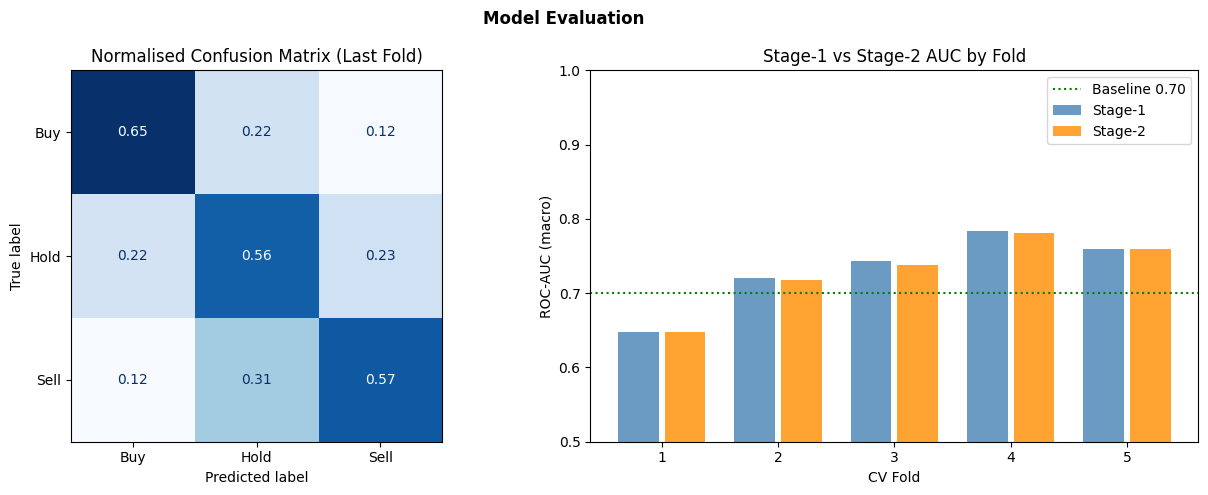

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Evaluation', fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_te_eval, y_pred_eval, normalize='true')
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=axes[0], colorbar=False, cmap='Blues', values_format='.2f')
axes[0].set_title('Normalised Confusion Matrix (Last Fold)')

# AUC comparison
x = cv_s1['fold']
axes[1].bar(x - 0.2, cv_s1['auc'], 0.35, color='steelblue',  alpha=0.8, label='Stage-1')
axes[1].bar(x + 0.2, cv_s2['auc'], 0.35, color='darkorange', alpha=0.8, label='Stage-2')
axes[1].axhline(0.70, color='green', linestyle=':', linewidth=1.5, label='Baseline 0.70')
axes[1].set_xlabel('CV Fold'); axes[1].set_ylabel('ROC-AUC (macro)')
axes[1].set_title('Stage-1 vs Stage-2 AUC by Fold')
axes[1].legend(); axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()


In [22]:
# Financial backtest on last fold
eval_df = df_model.iloc[te_last].copy().reset_index(drop=True)
eval_df['pred_signal'] = le.inverse_transform(y_pred_eval)
eval_df['confidence']  = proba_eval.max(axis=1)

def financial_metrics(sub, sig_col='pred_signal', ret_col='fwd_ret_5d'):
    sub = sub.sort_values('date').copy()
    pos = sub[sig_col].map({'Buy': 1, 'Hold': 0, 'Sell': -1})
    r   = pos * sub[ret_col]
    cum = (1 + r).cumprod()
    ann = (1 + cum.iloc[-1] - 1) ** (252/len(r)) - 1
    vol = r.std() * np.sqrt(252)
    return dict(
        total_return = float(cum.iloc[-1] - 1),
        ann_return   = float(ann),
        ann_vol      = float(vol),
        sharpe       = float(ann / (vol + 1e-9)),
        max_drawdown = float((cum / cum.cummax() - 1).min()),
        win_rate     = float((r > 0).mean()),
    )

strat_m = financial_metrics(eval_df)
bh_m    = financial_metrics(eval_df.assign(pred_signal='Buy'))

print(f"{'Metric':<18} {'Strategy':>12} {'Buy&Hold':>12}")
print("-" * 44)
for k in strat_m:
    print(f"{k:<18} {strat_m[k]:>12.4f} {bh_m[k]:>12.4f}")


Metric                 Strategy     Buy&Hold
--------------------------------------------
total_return       1445373458737571139670326089542636845748608514916352.0000      -1.0000
ann_return              47.9177      -0.5099
ann_vol                  0.6889       0.8165
sharpe                  69.5554      -0.6245
max_drawdown            -0.9409      -1.0000
win_rate                 0.4736       0.4357


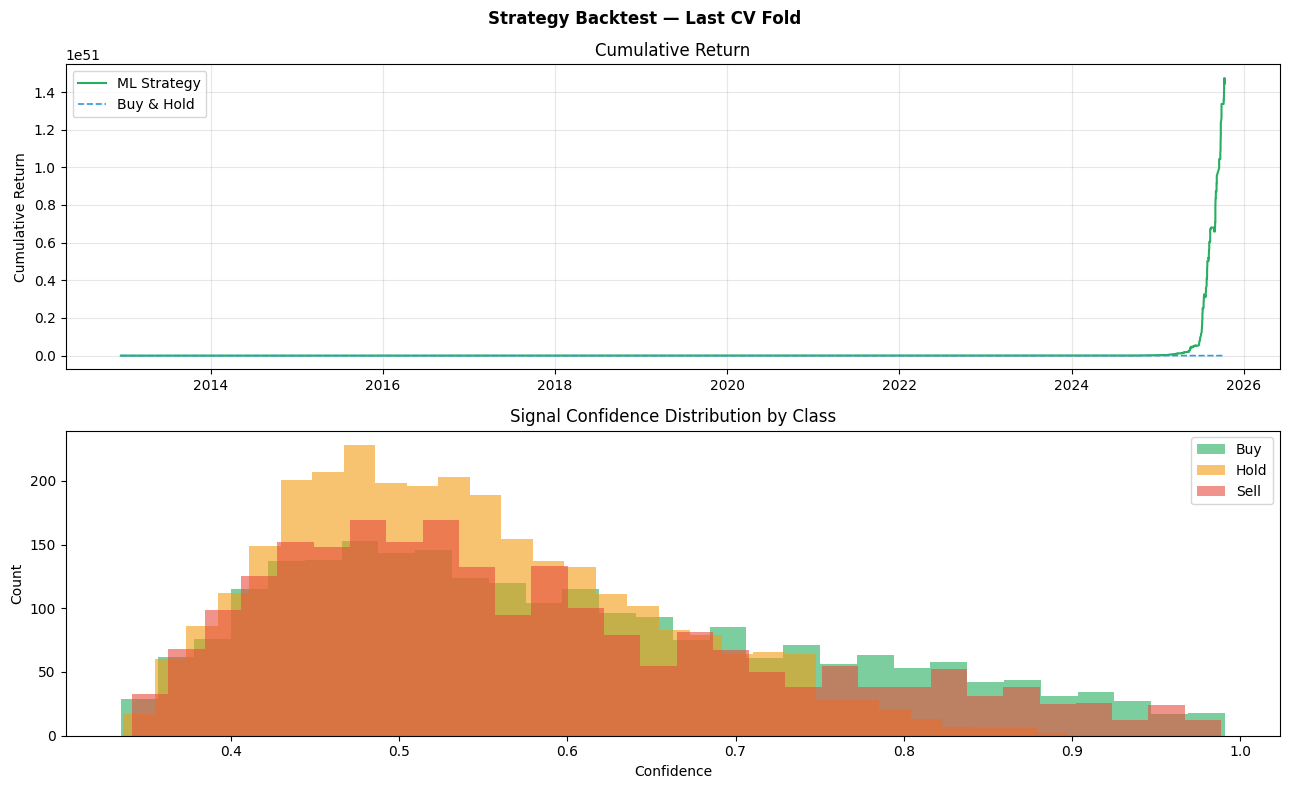

In [23]:
# Equity curve
ed = eval_df.sort_values('date').copy()
strat_curve = (1 + ed['pred_signal'].map({'Buy':1,'Hold':0,'Sell':-1}) * ed['fwd_ret_5d']).cumprod()
bh_curve    = (1 + ed['fwd_ret_5d']).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
fig.suptitle('Strategy Backtest — Last CV Fold', fontweight='bold')

axes[0].plot(ed['date'].values, strat_curve.values, color='#27ae60', lw=1.5, label='ML Strategy')
axes[0].plot(ed['date'].values, bh_curve.values,    color='#3498db', lw=1.2, ls='--', label='Buy & Hold')
axes[0].set_ylabel('Cumulative Return'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Cumulative Return')

for sig, col in [('Buy','#27ae60'),('Hold','#f39c12'),('Sell','#e74c3c')]:
    axes[1].hist(ed[ed['pred_signal']==sig]['confidence'], bins=30, alpha=0.6, color=col, label=sig)
axes[1].set_xlabel('Confidence'); axes[1].set_ylabel('Count')
axes[1].set_title('Signal Confidence Distribution by Class'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_equity_curve.png', dpi=120, bbox_inches='tight')
plt.show()


## 12. Market Regime Analysis — Strategy Performance by Regime

In [24]:
regimes = {
    'COVID (2020-2021)' : (eval_df['date'] >= '2020-01-01') & (eval_df['date'] <= '2021-12-31'),
    'Post-COVID (2022+)': eval_df['date'] >= '2022-01-01',
    'Bull Market'       : eval_df['nepse_bull_derived'] == 1,
    'Bear Market'       : eval_df['nepse_bull_derived'] == 0,
    'High Rate Regime'  : eval_df['high_rate_regime'] == 1,
    'Low Rate Regime'   : eval_df['high_rate_regime'] == 0,
}

print(f"{'Regime':<22} {'N':>6} {'Sharpe':>8} {'TotalRet%':>10} {'MaxDD%':>10} {'WinRate':>8}")
print("-" * 68)
for name, mask in regimes.items():
    sub = eval_df[mask]
    if len(sub) < 30:
        print(f"{name:<22}  too few rows ({len(sub)})")
        continue
    m = financial_metrics(sub)
    print(f"{name:<22} {len(sub):>6} {m['sharpe']:>8.2f} "
          f"{m['total_return']*100:>10.1f} {m['max_drawdown']*100:>10.1f} {m['win_rate']:>8.2f}")


Regime                      N   Sharpe  TotalRet%     MaxDD%  WinRate
--------------------------------------------------------------------
COVID (2020-2021)        1265   335.02 59295233518847.7      -43.6     0.53
Post-COVID (2022+)       2628    77.88 4588813021404961792.0      -44.4     0.46
Bull Market              3993   101.86 31795963375481916268336394534912.0      -91.1     0.49
Bear Market              3638    45.70 454577658701200414998528.0      -94.0     0.46
High Rate Regime         2750    70.00 106047782342571229184.0      -52.9     0.47
Low Rate Regime          4881    69.79 136294548250760295002630890115301376.0      -94.0     0.48


## 13. Save Model Artefacts

In [26]:
artifact = {
    'model'            : model_final,
    'selected_features': selected_features,
    'all_features'     : FEATURE_COLS,
    'label_encoder'    : le,
    'bank_encoder'     : bank_le,
    'cluster_map'      : cluster_map,
    'label_map'        : label_map,
    'model_params'     : MODEL_PARAMS,
    'forward_days'     : FORWARD_DAYS,
    'trained_on'       : str(datetime.date.today()),
    'cv_auc_mean'      : float(cv_s2['auc'].mean()),
    'cv_f1_mean'       : float(cv_s2['f1_macro'].mean()),
}

model_path = f'{OUTPUT_DIR}/nepse_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(artifact, f)

# Convert potential numpy types to native python types for JSON serialization
config = {
    'selected_features': [str(f) for f in selected_features],
    'forward_days'     : int(FORWARD_DAYS),
    'label_map'        : {str(k): int(v) for k, v in label_map.items()},
    'cluster_map'      : {str(k): int(v) for k, v in cluster_map.items()},
    'banks'            : [str(b) for b in bank_le.classes_],
    'cv_auc_mean'      : float(cv_s2['auc'].mean()),
}

with open(f'{OUTPUT_DIR}/feature_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f"Model saved        -> {model_path}")
print(f"Config saved       -> {OUTPUT_DIR}/feature_config.json")
print(f"Selected features  : {len(selected_features)}")
print(f"CV AUC  (mean)     : {cv_s2['auc'].mean():.4f}")
print(f"CV F1   (mean)     : {cv_s2['f1_macro'].mean():.4f}")

Model saved        -> nepse_model_output/nepse_model.pkl
Config saved       -> nepse_model_output/feature_config.json
Selected features  : 48
CV AUC  (mean)     : 0.7284
CV F1   (mean)     : 0.5459


## 14. Live Inference Pipeline

A **self-contained, production-ready** inference system.  
Accepts raw OHLCV data (last ~1 year from scraper) and emits  
`Buy / Sell / Hold` signals with confidence scores.

### Scraper → Inference Contract

| Column | Required | Notes |
|--------|----------|-------|
| `date` | ✅ | datetime or string |
| `open`, `high`, `low`, `close` | ✅ | daily OHLCV |
| `volume` | ✅ | shares traded |
| `nepse_close` | ✅ | NEPSE index close |
| `bank` | ✅ | ticker (e.g. `'NABIL'`) |
| `nepse_ret_1d/5d/21d` | optional | auto-derived if absent |
| `policy_rate` | ⚙️ | **manual input** |
| `car` | ⚙️ | **manual input** |
| `npl` | ⚙️ | **manual input** |

Minimum history required per bank: **≥ 252 rows** (~1 fiscal year)


In [27]:
def load_model_artifact(path: str = f'{OUTPUT_DIR}/nepse_model.pkl') -> dict:
    with open(path, 'rb') as f:
        return pickle.load(f)


def _derive_nepse_returns(df: pd.DataFrame) -> pd.DataFrame:
    """Re-derive NEPSE rolling returns from nepse_close if not already provided."""
    df = df.copy()
    nc = df['nepse_close']
    df['nepse_ret_1d']  = np.log(nc / nc.shift(1))
    df['nepse_ret_5d']  = np.log(nc / nc.shift(5))
    df['nepse_ret_21d'] = np.log(nc / nc.shift(21))
    return df


def prepare_live_features(
    raw: pd.DataFrame,
    policy_rate: float,
    car: float,
    npl: float,
    artifact: dict,
) -> pd.DataFrame:
    """
    Full feature pipeline for live inference.
    Identical to training — guarantees feature parity.
    """
    df = raw.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['bank', 'date']).reset_index(drop=True)

    # Inject macro inputs
    df['policy_rate'] = float(policy_rate)
    df['car']         = float(car)
    df['npl']         = float(npl)

    # Derive NEPSE returns if not present
    if 'nepse_ret_1d' not in df.columns:
        df = _derive_nepse_returns(df)

    # Feature engineering (identical to training function)
    df_fe = engineer_features(df)

    # Encode bank identity
    bank_enc = artifact['bank_encoder']
    known    = set(bank_enc.classes_)
    df_fe['bank_enc'] = df_fe['bank'].apply(
        lambda b: int(bank_enc.transform([b])[0]) if b in known else -1
    )

    # Cluster assignment
    df_fe['bank_cluster'] = df_fe['bank'].map(artifact['cluster_map']).fillna(-1).astype(int)

    # Verify all required features are present
    sel = artifact['selected_features']
    missing = [c for c in sel if c not in df_fe.columns]
    if missing:
        raise ValueError(f"Missing features after engineering: {missing}")

    return df_fe[['date', 'bank'] + sel]


def predict_signals(
    raw_ohlcv: pd.DataFrame,
    policy_rate: float,
    car: float,
    npl: float,
    model_path: str     = f'{OUTPUT_DIR}/nepse_model.pkl',
    min_confidence: float = 0.35,
    return_full_history: bool = False,
) -> pd.DataFrame:
    """
    End-to-end inference: raw OHLCV -> Buy/Sell/Hold + confidence.

    Parameters
    ----------
    raw_ohlcv        : Scraped DataFrame (see contract above).
                       Must contain >= 252 rows per bank.
    policy_rate      : Latest NRB policy rate (e.g., 5.5)
    car              : Latest published CAR % (e.g., 13.5)
    npl              : Latest published NPL % (e.g., 2.1)
    model_path       : Path to saved model pkl
    min_confidence   : Flag signals below this threshold
    return_full_history : If True, return all rows; if False, only latest per bank

    Returns
    -------
    DataFrame with columns:
        date, bank, signal, confidence,
        prob_buy, prob_hold, prob_sell,
        low_confidence_flag
    """
    artifact = load_model_artifact(model_path)
    model    = artifact['model']
    le_inf   = artifact['label_encoder']
    sel_feat = artifact['selected_features']

    df_inf = prepare_live_features(raw_ohlcv, policy_rate, car, npl, artifact)
    df_inf = df_inf.dropna(subset=sel_feat).reset_index(drop=True)

    if df_inf.empty:
        raise ValueError(
            "No valid rows after feature engineering. "
            "Ensure >= 252 rows of history per bank."
        )

    X_inf  = df_inf[sel_feat].values
    proba  = model.predict_proba(X_inf)
    labels = le_inf.inverse_transform(model.predict(X_inf))

    classes = le_inf.classes_   # e.g. ['Buy', 'Hold', 'Sell']
    prob_d  = {cls: proba[:, i] for i, cls in enumerate(classes)}

    result = df_inf[['date', 'bank']].copy()
    result['signal']              = labels
    result['confidence']          = proba.max(axis=1)
    result['prob_buy']            = prob_d.get('Buy',  np.zeros(len(result)))
    result['prob_hold']           = prob_d.get('Hold', np.zeros(len(result)))
    result['prob_sell']           = prob_d.get('Sell', np.zeros(len(result)))
    result['low_confidence_flag'] = result['confidence'] < min_confidence

    if return_full_history:
        return result.reset_index(drop=True)

    # Return ONE prediction per bank — the most recent trading date
    return (result.sort_values('date')
                  .groupby('bank').tail(1)
                  .sort_values('confidence', ascending=False)
                  .reset_index(drop=True))


print("Inference functions loaded successfully")
print()
print("Quick-start usage:")
print("""
  import pandas as pd

  scraped = pd.read_csv('live_ohlcv.csv')   # from your scraper

  signals = predict_signals(
      raw_ohlcv    = scraped,
      policy_rate  = 5.5,     # latest NRB policy rate
      car          = 13.5,    # latest published industry CAR
      npl          = 2.1,     # latest published industry NPL
  )
  print(signals)
""")


Inference functions loaded successfully

Quick-start usage:

  import pandas as pd
  
  scraped = pd.read_csv('live_ohlcv.csv')   # from your scraper
  
  signals = predict_signals(
      raw_ohlcv    = scraped,
      policy_rate  = 5.5,     # latest NRB policy rate
      car          = 13.5,    # latest published industry CAR
      npl          = 2.1,     # latest published industry NPL
  )
  print(signals)



## 15. Inference Demo — Simulated Live Prediction

In [29]:
# Simulate scraper output: increased lookback to ensure 252-day features have enough warm-up data
LOOKBACK_DAYS = 500
last_date = df_raw['date'].max()
cutoff    = last_date - pd.Timedelta(days=LOOKBACK_DAYS)

SCRAPER_COLS = ['date','bank','open','high','low','close','volume','nepse_close']
live_sim = df_raw[df_raw['date'] >= cutoff][SCRAPER_COLS].copy().reset_index(drop=True)

print(f"Simulated live feed : {live_sim.shape}")
print(f"Date range          : {live_sim['date'].min().date()} to {live_sim['date'].max().date()}")

# Use latest macro from dataset as proxy for manual inputs
row_last      = df_raw.sort_values('date').iloc[-1]
live_policy   = float(row_last['policy_rate'])
live_car      = float(row_last['car'])
live_npl      = float(row_last['npl'])

signals = predict_signals(
    raw_ohlcv    = live_sim,
    policy_rate  = live_policy,
    car          = live_car,
    npl          = live_npl,
)

# Pretty-print table
SYM  = {'Buy': '🟢 BUY ', 'Sell': '🔴 SELL', 'Hold': '🟡 HOLD'}
WARN = '  ⚠️ low conf'
print()
print(f"{'='*68}")
print(f"  NEPSE BANK SIGNALS  —  as of {last_date.date()}")
print(f"  Policy Rate: {live_policy}%  |  CAR: {live_car}%  |  NPL: {live_npl}%")
print(f"{'='*68}")
print(f"  {'Bank':<8}  {'Signal':<10}  {'Conf':>6}  {'P(Buy)':>7}  {'P(Hold)':>7}  {'P(Sell)':>7}")
print(f"  {'-'*60}")
for _, r in signals.iterrows():
    flag = WARN if r['low_confidence_flag'] else ''
    print(f"  {r['bank']:<8}  {SYM[r['signal']]:<10}  {r['confidence']:>6.3f}"
          f"  {r['prob_buy']:>7.3f}  {r['prob_hold']:>7.3f}  {r['prob_sell']:>7.3f}{flag}")
print(f"{'='*68}")
print("  Legend: 🟢 BUY  🟡 HOLD  🔴 SELL  ⚠️ Low confidence (<0.35)")

Simulated live feed : (5270, 8)
Date range          : 2024-06-06 to 2025-10-19

  NEPSE BANK SIGNALS  —  as of 2025-10-19
  Policy Rate: 4.5%  |  CAR: 17.16%  |  NPL: 2.14%
  Bank      Signal        Conf   P(Buy)  P(Hold)  P(Sell)
  ------------------------------------------------------------
  GBIME     🔴 SELL       0.652    0.141    0.207    0.652
  NMB       🟡 HOLD       0.559    0.144    0.559    0.297
  PCBL      🔴 SELL       0.480    0.184    0.336    0.480
  NICA      🟡 HOLD       0.479    0.249    0.479    0.272
  EBL       🟡 HOLD       0.455    0.265    0.455    0.279
  PRVU      🔴 SELL       0.436    0.193    0.371    0.436
  SBL       🔴 SELL       0.428    0.177    0.395    0.428
  KBL       🟡 HOLD       0.426    0.224    0.426    0.350
  SANIMA    🟡 HOLD       0.424    0.378    0.424    0.198
  HBL       🟡 HOLD       0.415    0.249    0.415    0.336
  NBL       🟡 HOLD       0.412    0.202    0.412    0.386
  SCB       🔴 SELL       0.412    0.229    0.360    0.412
  SBI     

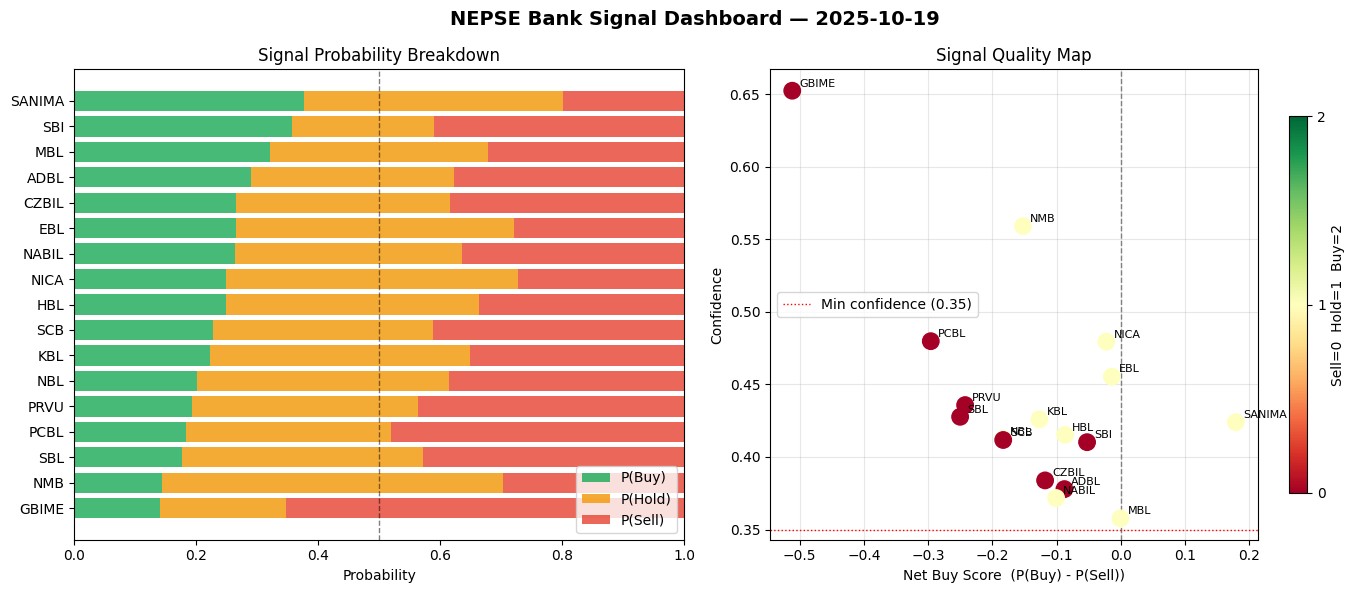

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'NEPSE Bank Signal Dashboard — {last_date.date()}', fontweight='bold', fontsize=14)

sigs = signals.sort_values('prob_buy', ascending=True)

# Stacked probability bars
axes[0].barh(sigs['bank'], sigs['prob_buy'],
             color='#27ae60', alpha=0.85, label='P(Buy)')
axes[0].barh(sigs['bank'], sigs['prob_hold'],
             left=sigs['prob_buy'], color='#f39c12', alpha=0.85, label='P(Hold)')
axes[0].barh(sigs['bank'], sigs['prob_sell'],
             left=sigs['prob_buy']+sigs['prob_hold'],
             color='#e74c3c', alpha=0.85, label='P(Sell)')
axes[0].axvline(0.5, color='black', lw=1, ls='--', alpha=0.5)
axes[0].set_xlim(0, 1); axes[0].set_xlabel('Probability')
axes[0].set_title('Signal Probability Breakdown')
axes[0].legend(loc='lower right')

# Signal quality map
sig_num = signals['signal'].map({'Buy':2,'Hold':1,'Sell':0})
sc = axes[1].scatter(signals['prob_buy'] - signals['prob_sell'],
                     signals['confidence'],
                     c=sig_num, cmap='RdYlGn', s=140, vmin=0, vmax=2, zorder=3)
for _, r in signals.iterrows():
    axes[1].annotate(r['bank'],
                     (r['prob_buy']-r['prob_sell'], r['confidence']),
                     xytext=(5, 3), textcoords='offset points', fontsize=8)
axes[1].axvline(0, color='gray', lw=1, ls='--')
axes[1].axhline(0.35, color='red', lw=1, ls=':', label='Min confidence (0.35)')
axes[1].set_xlabel('Net Buy Score  (P(Buy) - P(Sell))')
axes[1].set_ylabel('Confidence')
axes[1].set_title('Signal Quality Map')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.colorbar(sc, ax=axes[1], ticks=[0,1,2], label='Sell=0  Hold=1  Buy=2', shrink=0.8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_signal_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()


## 16. System Summary

| Component | Detail |
|-----------|--------|
| **Model** | `HistGradientBoostingClassifier` (scikit-learn) |
| **Why HGB** | Fast, tabular-native, built-in class balancing, NaN-safe, no external deps |
| **Target** | 5-day forward log-return → Buy/Sell/Hold (adaptive per-bank percentile thresholds) |
| **Feature engineering** | 55 candidate features → permutation-selected subset |
| **Feature categories** | Log returns, SMA/EMA, RSI(14/28), MACD, volatility, ATR, Bollinger, candle structure, OBV, alpha vs NEPSE, 52-week position, regime flags, macro |
| **Class imbalance** | `class_weight='balanced'` native to model |
| **Validation** | `TimeSeriesSplit(n_splits=5, gap=5)` → no future bleed |
| **Final training** | 100% of data retrained after CV evaluation |
| **Bank encoding** | Label encoder + K-Means cluster (3 groups) |
| **Regime features** | COVID flag, high-rate regime, NEPSE bull/bear (re-derived), rolling z-scores, fiscal quarter |
| **Macro inputs** | `policy_rate`, `car`, `npl` — manual input at inference time |
| **Inference contract** | `predict_signals(raw_ohlcv, policy_rate, car, npl)` |
| **Output** | `signal`, `confidence`, `prob_buy`, `prob_hold`, `prob_sell`, `low_confidence_flag` |
| **Artefacts** | `nepse_model_output/nepse_model.pkl`, `feature_config.json`, 7 PNG charts |

### Deployment Checklist
- Provide **≥ 252 rows** of OHLCV history per bank to the inference function
- Include `nepse_close` column (NEPSE index daily close)
- Pass latest `policy_rate`, `car`, `npl` as manual arguments
- All features derived from raw OHLCV — **zero dependency on training data at inference**
- `low_confidence_flag=True` means the model is uncertain — consider filtering these signals
